In [1]:
# Run once in Colab
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy psycopg2-binary -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine, text

In [3]:
pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
df=pd.read_csv('data/IDS_ALLCountries_Data.csv',encoding='latin1')


#Step 1 ---- Data Collection

In [5]:
df.head()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
0,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.DPPG,NaN,NaN,NaN,NaN,NaN,NaN,10.2500,8.0833,9.9575,0.0,7.8333,0.0,0.0,0.0,29.8333,0.0,0.0,19.8356,0.0,17.9041,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.OFFT,NaN,NaN,NaN,NaN,NaN,NaN,10.2500,8.0833,9.9575,0.0,7.8333,0.0,0.0,0.0,29.8333,0.0,0.0,19.8356,0.0,17.9041,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.PRVT,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.DPPG,NaN,NaN,NaN,NaN,NaN,NaN,50.6176,43.0248,58.0061,0.0,21.2119,0.0,0.0,0.0,81.9289,0.0,0.0,64.2646,0.0,73.0790,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.OFFT,NaN,NaN,NaN,NaN,NaN,NaN,50.6176,43.0248,58.0061,0.0,21.2119,0.0,0.0,0.0,81.9289,0.0,0.0,64.2646,0.0,73.0790,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes)

Shape: (62983, 39)

Columns:
['Country Name', 'Country Code', 'Counterpart-Area Name', 'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030', '2031', '2032']

Data types:


Country Name                 str
Country Code                 str
Counterpart-Area Name        str
Counterpart-Area Code        str
Series Name                  str
Series Code                  str
2000                     float64
2001                     float64
2002                     float64
2003                     float64
2004                     float64
2005                     float64
2006                     float64
2007                     float64
2008                     float64
2009                     float64
2010                     float64
2011                     float64
2012                     float64
2013                     float64
2014                     float64
2015                     float64
2016                     float64
2017                     float64
2018                     float64
2019                     float64
2020                     float64
2021                     float64
2022                     float64
2023                     float64
2024      

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62983 entries, 0 to 62982
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country Name           62980 non-null  str    
 1   Country Code           62978 non-null  str    
 2   Counterpart-Area Name  62978 non-null  str    
 3   Counterpart-Area Code  62978 non-null  str    
 4   Series Name            62978 non-null  str    
 5   Series Code            62978 non-null  str    
 6   2000                   49490 non-null  float64
 7   2001                   49434 non-null  float64
 8   2002                   49262 non-null  float64
 9   2003                   49001 non-null  float64
 10  2004                   49195 non-null  float64
 11  2005                   49137 non-null  float64
 12  2006                   49394 non-null  float64
 13  2007                   49645 non-null  float64
 14  2008                   49497 non-null  float64
 15  2009         

In [8]:
df['Country Name'].unique()

<ArrowStringArray>
[                                      'Afghanistan',
                                           'Albania',
                                           'Algeria',
                                            'Angola',
                                         'Argentina',
                                           'Armenia',
                                        'Azerbaijan',
                                        'Bangladesh',
                                           'Belarus',
                                            'Belize',
 ...
                               'Upper middle income',
                                        'Uzbekistan',
                                           'Vanuatu',
                                          'Viet Nam',
                                       'Yemen, Rep.',
                                            'Zambia',
                                          'Zimbabwe',
                                                 nan,
 'Da

In [9]:
df['Series Name'].unique()

<ArrowStringArray>
[          'Average grace period on new external debt commitments (years)',
 'Average grace period on new external debt commitments, official (years)',
  'Average grace period on new external debt commitments, private (years)',
              'Average grant element on new external debt commitments (%)',
    'Average grant element on new external debt commitments, official (%)',
     'Average grant element on new external debt commitments, private (%)',
                   'Average interest on new external debt commitments (%)',
         'Average interest on new external debt commitments, official (%)',
          'Average interest on new external debt commitments, private (%)',
               'Average maturity on new external debt commitments (years)',
 ...
                                          'PRVG, bonds (NFL, current US$)',
                                          'PRVG, bonds (NTR, current US$)',
                                          'PRVG, bonds (TDS, cur

In [10]:
df['Country Name'].nunique()

136

In [11]:
df[['Country Name','Series Name']].describe()

,Country Name,Series Name
count,62980,62978
unique,136,576
top,Europe & Central Asia (excluding high income),Average grace period on new external debt comm...
freq,574,134


In [12]:
df.isnull().sum() / len(df) * 100

Country Name              0.004763
Country Code              0.007939
Counterpart-Area Name     0.007939
Counterpart-Area Code     0.007939
Series Name               0.007939
Series Code               0.007939
2000                     21.423241
2001                     21.512154
2002                     21.785244
2003                     22.199641
2004                     21.891622
2005                     21.983710
2006                     21.575663
2007                     21.177143
2008                     21.412127
2009                     20.981852
2010                     20.992966
2011                     22.074211
2012                     22.188527
2013                     21.599479
2014                     19.813283
2015                     19.929187
2016                     20.308655
2017                     20.084785
2018                     20.143531
2019                     19.830748
2020                     19.095629
2021                     19.459219
2022                

In [13]:
np.random.get_state()

('MT19937',
 array([2147483648, 1535310609, 1722959684, 3528265978, 3576137187,
         334439292, 1198673012, 1247378446,  489031282, 3723003771,
         564429682, 3787188812,  980144015,  101986823, 4000525205,
        1330707655,   51755617,  148153031, 2169663844, 2049294994,
        1756563383,  712134753, 2146036399, 3163805892, 3342857131,
        3603645144, 2498203121,   71966141, 2917957320, 3018928482,
        2429282541,  720829281, 4061270438, 1525768802,  830808051,
        2976094420, 3578581256, 1151208461,   36408749, 2358178265,
        1431946125, 4163726014,   62061796, 3974503953, 3296976359,
        1747526714,  271026753, 1237441366,  182595094, 1814900286,
         723187628, 2954114467, 2019814119, 1205720526, 4002748243,
        3969392079, 1922224774, 2300724529, 2252002220, 3754359089,
        2056195115, 2455038151, 2059163162, 3195625710, 3842820664,
        1812741279,  831638375,  571462840, 1325750465, 1181927137,
        3816175472,  741222009, 4184

In [14]:
df.shape

(62983, 39)

In [15]:
if 'df' not in globals():
   # '---- Synthetic sample generator (World-Bank-IDS-like schema) ----
  np.random.seed(42)

  countries = ['India', 'Brazil', 'Nigeria', 'Pakistan', 'Bangladesh', 'Kenya',
                 'Indonesia', 'Vietnam', 'Egypt', 'Philippines', 'Mexico',
                 'South Africa', 'Turkey', 'Ethiopia', 'Ghana']

  indicators = {
        'DT.DOD.DECT.CD': 'External debt stocks, total (DOD, current US$)',
        'DT.AMT.DECT.CD': 'Principal repayments on external debt, total (current US$)',
        'DT.INT.DECT.CD': 'Interest payments on external debt, total (current US$)',
        'DT.DIS.DECT.CD': 'Disbursements on external debt, total (current US$)',
        'DT.DOD.DLXF.CD': 'External debt stocks, long-term (DOD, current US$)',
        'DT.DOD.DSTC.CD': 'External debt stocks, short-term (DOD, current US$)',
    }

  rows = []
  for c in countries:
        base = np.random.uniform(5e9, 3e11)
        for code_, name in indicators.items():
            value = base * np.random.uniform(0.05, 1.0)
            # inject some missing values and duplicates deliberately
            if np.random.rand() < 0.08:
                value = np.nan
            rows.append({
                'country_name': c,
                'country_code': c[:3].upper(),
                'indicator_name': name,
                'indicator_code': code_,
                'debt_value': value
            })

  df = pd.DataFrame(rows)
    # inject a few duplicate rows to simulate real messy data
  df = pd.concat([df, df.sample(5, random_state=1)], ignore_index=True)
  print("Synthetic dataset generated:", df.shape)

else:
  df = pd.read_csv('data/IDS_ALLCountries_Data.csv',encoding='latin1')
  print("Loaded CSV:", df.shape)




Loaded CSV: (62983, 39)


In [16]:
countries = ['India', 'Brazil', 'Nigeria', 'Pakistan', 'Bangladesh', 'Kenya',
                 'Indonesia', 'Vietnam', 'Egypt', 'Philippines', 'Mexico',
                 'South Africa', 'Turkey', 'Ethiopia', 'Ghana']

indicators = {
        'DT.DOD.DECT.CD': 'External debt stocks, total (DOD, current US$)',
        'DT.AMT.DECT.CD': 'Principal repayments on external debt, total (current US$)',
        'DT.INT.DECT.CD': 'Interest payments on external debt, total (current US$)',
        'DT.DIS.DECT.CD': 'Disbursements on external debt, total (current US$)',
        'DT.DOD.DLXF.CD': 'External debt stocks, long-term (DOD, current US$)',
        'DT.DOD.DSTC.CD': 'External debt stocks, short-term (DOD, current US$)',
    }

In [17]:
df[df['Country Name'].isin(countries)]['Country Name'].unique()

<ArrowStringArray>
[  'Bangladesh',       'Brazil',     'Ethiopia',        'Ghana',
        'India',    'Indonesia',        'Kenya',       'Mexico',
      'Nigeria',     'Pakistan',  'Philippines', 'South Africa']
Length: 12, dtype: str

In [18]:
df[df['Series Code'].isin(indicators)]['Series Code'].unique()

<ArrowStringArray>
['DT.DOD.DLXF.CD', 'DT.DOD.DSTC.CD', 'DT.DOD.DECT.CD', 'DT.INT.DECT.CD']
Length: 4, dtype: str

In [19]:
print(df.shape)
print(df.dtypes)
df.info()


(62983, 39)
Country Name                 str
Country Code                 str
Counterpart-Area Name        str
Counterpart-Area Code        str
Series Name                  str
Series Code                  str
2000                     float64
2001                     float64
2002                     float64
2003                     float64
2004                     float64
2005                     float64
2006                     float64
2007                     float64
2008                     float64
2009                     float64
2010                     float64
2011                     float64
2012                     float64
2013                     float64
2014                     float64
2015                     float64
2016                     float64
2017                     float64
2018                     float64
2019                     float64
2020                     float64
2021                     float64
2022                     float64
2023                     float6

In [20]:
filtered_df=df[df['Country Name'].isin(countries)&df['Series Code'].isin(indicators.keys())]
print("Total rows collected:",filtered_df.shape[0])
filtered_df.head(48)

Total rows collected: 48


,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
3361,Bangladesh,BGD,World,WLD,"External debt stocks, long-term (DOD, current ...",DT.DOD.DLXF.CD,1.498946e+10,1.441023e+10,1.598082e+10,1.767980e+10,1.869827e+10,1.743890e+10,1.843556e+10,1.957890e+10,2.069522e+10,2.196981e+10,2.222150e+10,2.367194e+10,2.598594e+10,2.722549e+10,2.965082e+10,3.046137e+10,3.218816e+10,3.867809e+10,4.655972e+10,5.131723e+10,6.045549e+10,7.008839e+10,7.543368e+10,8.320755e+10,8.687461e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3368,Bangladesh,BGD,World,WLD,"External debt stocks, short-term (DOD, current...",DT.DOD.DSTC.CD,3.340000e+08,3.607430e+08,5.720940e+08,6.170000e+08,7.120000e+08,6.884281e+08,1.178000e+09,1.369670e+09,1.893536e+09,1.933322e+09,2.947347e+09,2.103336e+09,1.957166e+09,3.732780e+09,4.151020e+09,6.630821e+09,7.834619e+09,1.076494e+10,9.029402e+09,9.737331e+09,1.098646e+10,1.808820e+10,1.853007e+10,1.423111e+10,1.294522e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3369,Bangladesh,BGD,World,WLD,"External debt stocks, total (DOD, current US$)",DT.DOD.DECT.CD,1.560056e+10,1.497880e+10,1.668759e+10,1.844038e+10,1.971407e+10,1.850309e+10,2.016093e+10,2.152354e+10,2.334692e+10,2.537780e+10,2.657176e+10,2.704608e+10,2.915598e+10,3.245469e+10,3.527184e+10,3.870494e+10,4.156925e+10,5.106828e+10,5.712546e+10,6.246833e+10,7.355086e+10,9.147759e+10,9.694443e+10,1.010000e+11,1.040000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3456,Bangladesh,BGD,World,WLD,"Interest payments on external debt, total (INT...",DT.INT.DECT.CD,1.976131e+08,1.816041e+08,1.735197e+08,1.743441e+08,2.014341e+08,2.372666e+08,2.312272e+08,2.642473e+08,2.636317e+08,2.389428e+08,2.402728e+08,3.157536e+08,3.342717e+08,3.636809e+08,4.119835e+08,4.185468e+08,5.139445e+08,7.971447e+08,9.402071e+08,1.139480e+09,1.048309e+09,1.094445e+09,1.499453e+09,2.673899e+09,3.395690e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7000,Brazil,BRA,World,WLD,"External debt stocks, long-term (DOD, current ...",DT.DOD.DLXF.CD,2.090000e+11,1.930000e+11,1.870000e+11,1.820000e+11,1.700000e+11,1.640000e+11,1.730000e+11,1.990000e+11,2.260000e+11,2.370000e+11,2.820000e+11,3.570000e+11,4.030000e+11,4.460000e+11,4.950000e+11,4.870000e+11,4.820000e+11,4.860000e+11,4.870000e+11,4.860000e+11,4.760000e+11,4.740000e+11,4.940000e+11,5.090000e+11,5.040000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7008,Brazil,BRA,World,WLD,"External debt stocks, short-term (DOD, current...",DT.DOD.DSTC.CD,3.097317e+10,2.827327e+10,2.339501e+10,2.459424e+10,2.526702e+10,2.399300e+10,2.032301e+10,3.924610e+10,3.664410e+10,3.978608e+10,6.549234e+10,4.214033e+10,3.258303e+10,3.350651e+10,5.817694e+10,5.234144e+10,5.720175e+10,5.240839e+10,6.684389e+10,7.917937e+10,6.898307e+10,7.875296e+10,6.777150e+10,8.049160e+10,8.428223e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7009,Brazil,BRA,World,WLD,"External debt stocks, total (DOD, current US$)",DT.DOD.DECT.CD,2.430000e+11,2.300000e+11,2.320000e+11,2.360000e+11,2.210000e+11,1.880000e+11,1.940000e+11,2.380000e+11,2.630000e+11,2.820000e+11,3.520000e+11,4.040000e+11,4.400000e+11,4.840000e+11,5.570000e+11,5.430000e+11,5.430000e+11,5.430000e+11,5.580000e+11,5.690000e+11,5.490000e+11,5.710000e+11,5.790000e+11,6.070000e+11,6.050000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7103,Brazil,BRA,World,WLD,"Interest payments on external debt, total (INT...",DT.INT.DECT.CD,1.714814e+10,1.720647e+10,1.496472e+10,1.635087e+10,1.475786e+10,1.330836e+10,1.481708e+10,1.454261e+10,1.618843e+10,1.405367e+10,1.385531e+10,1.729254e+10,1.490672e+10,1.834717e+10,1.722500e+10,1.850296e+10,2.278659e+10,1.976619e+10,2.101735e+10,2.836818e+10,2.023094e+10,2.961357e+10,1.958525e+10,2.995850e+10,3.047523e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17811,Ethiopia,ETH,World,WLD,"External debt stocks, long-term (DOD, current ...",DT.DOD.DLXF.CD,5.338841e+09,5.572556e+09,6.337040

#Step 2 -------Data Cleaning

In [21]:
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary

,missing_count,missing_pct
Country Name,3,0.00
Country Code,5,0.01
Counterpart-Area Name,5,0.01
Counterpart-Area Code,5,0.01
Series Name,5,0.01
Series Code,5,0.01
2000,13493,21.42
2001,13549,21.51
2002,13721,21.79
2003,13982,22.20


In [22]:
df.columns

Index(['Country Name', 'Country Code', 'Counterpart-Area Name',
       'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028',
       '2029', '2030', '2031', '2032'],
      dtype='str')

In [23]:
Year_columns=[str(Year) for Year in range(2000,2033)]

In [24]:
df.columns

Index(['Country Name', 'Country Code', 'Counterpart-Area Name',
       'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028',
       '2029', '2030', '2031', '2032'],
      dtype='str')

In [25]:
Year = [str(Year) for Year in range(2000, 2028)]  # 2000 to 2027 inclusive

# Keep only the Year columns that actually exist in the dataset
Year = [c for c in Year if c in df.columns]

print(f"Using {len(Year)} year columns: {Year[0]} to {Year[-1]}")


Using 28 year columns: 2000 to 2027


#### Check missing values before filling

In [26]:
# Forward fill across the year columns (left to right)
df[Year_columns] = df[Year_columns].ffill(axis=1)
print("Missing values remaining after Forward Fill:", df[Year_columns].isnull().sum().sum())

# Backward fill across the year columns (right to left) to catch leading gaps
df[Year_columns] = df[Year_columns].bfill(axis=1)
print("Missing values remaining after Backward Fill:", df[Year_columns].isnull().sum().sum())

# Any rows that were entirely empty (ffill/bfill couldn't help) -> fill with 0
df[Year_columns] = df[Year_columns].fillna(0)
print("Missing values remaining after final fillna(0):", df[Year_columns].isnull().sum().sum())

Missing values remaining after Forward Fill: 213121
Missing values remaining after Backward Fill: 110385
Missing values remaining after final fillna(0): 0


In [27]:
df_melted = df.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=Year_columns,
    var_name="Year",
    value_name="debt_value",
)
df

df = df_melted.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="debt_value",
    aggfunc="sum",
).reset_index()


df.columns.name = None
df.reset_index(drop=True, inplace=True)
df.head()

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term (AMT, current US$)","Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)"
0,Afghanistan,AFG,2000,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2
1,Afghanistan,AFG,2001,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2
2,Afghanistan,AFG,2002,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2
3,Afghanistan,AFG,2003,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,3493000.0,NaN,NaN,5130000.0,3493000.0,3493

In [28]:
debt_indicators=[
    c
    for c in df.columns
    if c not in ["Country Name", "Country Code", "Year"]
]

df["debt_value"]=df[debt_indicators].sum(axis=1)
df[['Country Name', 'Country Code', 'Year','debt_value']].head()

,Country Name,Country Code,Year,debt_value
0,Afghanistan,AFG,2000,4.591343e+10
1,Afghanistan,AFG,2001,4.591343e+10
2,Afghanistan,AFG,2002,4.591343e+10
3,Afghanistan,AFG,2003,4.591343e+10
4,Afghanistan,AFG,2004,4.591343e+10


In [29]:
df.head()

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
0,Afghanistan,AFG,2000,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
1,Afghanistan,AFG,2001,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
2,Afghanistan,AFG,2002,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
3,Afghanistan,AFG,2003,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0

In [30]:
df['Year'].head()

0    2000
1    2001
2    2002
3    2003
4    2004
Name: Year, dtype: str

In [31]:
df.head(15)

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
0,Afghanistan,AFG,2000,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,2.315706e+08,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
1,Afghanistan,AFG,2001,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,2.315706e+08,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
2,Afghanistan,AFG,2002,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,NaN,-47334000.0,1.9553,843810000.0,94882000.0,2.315706e+08,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
3,Afghanistan,AFG,2003,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3493000.0,NaN,NaN,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0

#### Final check — confirm no missing values remain

In [32]:
df.isnull().sum().to_frame('missing_count')

,missing_count
Country Name,0
Country Code,0
Year,0
Average grace period on new external debt commitments (years),0
"Average grace period on new external debt commitments, official (years)",0
...,...
"Undisbursed external debt, private creditors (UND, current US$)",99
"Undisbursed external debt, total (UND, current US$)",0
"Use of IMF credit (DOD, current US$)",0
"Use of IMF credit and SDR allocations (DOD, current US$)",0


In [33]:
df.fillna(0, inplace=True)
df.isnull().sum().to_frame('missing_count')

,missing_count
Country Name,0
Country Code,0
Year,0
Average grace period on new external debt commitments (years),0
"Average grace period on new external debt commitments, official (years)",0
...,...
"Undisbursed external debt, private creditors (UND, current US$)",0
"Undisbursed external debt, total (UND, current US$)",0
"Use of IMF credit (DOD, current US$)",0
"Use of IMF credit and SDR allocations (DOD, current US$)",0


In [34]:
df['Year'].head()

0    2000
1    2001
2    2002
3    2003
4    2004
Name: Year, dtype: str

In [35]:
df['Country Name'].shape

(4422,)

In [36]:
missing_rows =df[df['Country Name'].isnull()]
missing_rows

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value


In [37]:
df = df.dropna(subset=['Country Name'])

In [38]:
df.columns

Index(['Country Name', 'Country Code', 'Year',
       'Average grace period on new external debt commitments (years)',
       'Average grace period on new external debt commitments, official (years)',
       'Average grace period on new external debt commitments, private (years)',
       'Average grant element on new external debt commitments (%)',
       'Average grant element on new external debt commitments, official (%)',
       'Average grant element on new external debt commitments, private (%)',
       'Average interest on new external debt commitments (%)',
       ...
       'Total external debt per capita (US$)',
       'Total reserves (% of total external debt)',
       'Total reserves (includes gold, current US$)',
       'Total reserves in months of imports',
       'Undisbursed external debt, official creditors (UND, current US$)',
       'Undisbursed external debt, private creditors (UND, current US$)',
       'Undisbursed external debt, total (UND, current US$)',
       

In [39]:
print("Remaining nulls:\n", df.isnull().sum())

Remaining nulls:
 Country Name                                                               0
Country Code                                                               0
Year                                                                       0
Average grace period on new external debt commitments (years)              0
Average grace period on new external debt commitments, official (years)    0
                                                                          ..
Undisbursed external debt, private creditors (UND, current US$)            0
Undisbursed external debt, total (UND, current US$)                        0
Use of IMF credit (DOD, current US$)                                       0
Use of IMF credit and SDR allocations (DOD, current US$)                   0
debt_value                                                                 0
Length: 580, dtype: int64


In [40]:
print("Duplicate rows before:", df.duplicated().sum())

Duplicate rows before: 0


In [41]:
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows after: 0


In [42]:
df['Year']

0       2000
1       2001
2       2002
3       2003
4       2004
        ... 
4417    2028
4418    2029
4419    2030
4420    2031
4421    2032
Name: Year, Length: 4422, dtype: str

In [43]:
df['Year']=pd.to_numeric(df['Year'],errors='coerce')

In [44]:
df=df[df['Year'] <= 2026.0]
df.reset_index(drop=True, inplace=True)
df.tail()

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
3613,Zimbabwe,ZWE,2022,4.8333,4.8333,0.0,34.5311,34.5311,0.0,0.9999,0.9999,0.0,19.3333,19.3333,0.0,7800231.6,0.0,2677927.2,59802.1,0.0,0.0,7800231.6,0.0,0.0,0.0,...,289709832.7,41084.7,0.0,2.663430e+08,23366832.7,23366832.7,0.0,0.0,0.0,6044956.2,28.1510,61195917.0,0.0,9724957.9,6.084244,878.756207,4.228013,597028557.8,0.702438,798779924.9,6363256.1,805143181.0,0.0,1.352160e+09,1.862859e+11
3614,Zimbabwe,ZWE,2023,1.1226,1.1226,0.0,-6.2098,-6.2098,0.0,9.0710,9.0710,0.0,9.2612,9.2612,0.0,2642359.2,0.0,0.0,59802.1,-2642359.2,-2642000.0,2642359.2,0.0,0.0,0.0,...,994263094.5,45414.9,0.0,9.222610e+08,72002094.5,72002094.5,0.0,0.0,0.0,-1478546.3,27.0548,38820981.0,0.0,427751406.9,19.516072,890.318376,0.755537,109919572.7,0.122868,764733094.0,6657337.6,771390431.6,0.0,1.363159e+09,2.146760e+11
3615,Zimbabwe,ZWE,2024,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,2642359.2,0.0,0.0,59802.1,-2642359.2,-2642000.0,2642359.2,0.0,0.0,0.0,...,945798173.8,19480.4,0.0,8.907740e+08,55024173.8,55024173.8,0.0,0.0,0.0,-662252.4,27.5425,38820981.0,0.0,-144793774.6,19.516072,865.902209,3.365870,484811134.7,0.122868,688108369.0,6350490.5,694458859.5,0.0,1.325023e+09,2.064356e+11
3616,Zimbabwe,ZWE,2025,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,2642359.2,0.0,0.0,59802.1,-2642359.2,-2642000.0,2642359.2,0.

In [45]:
df.head()

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
0,Afghanistan,AFG,2000,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
1,Afghanistan,AFG,2001,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
2,Afghanistan,AFG,2002,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
3,Afghanistan,AFG,2003,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0

#Step 3 -------Data Preprocessing &Transformation

In [46]:
df['Year']=(df['Year'].apply(pd.to_numeric,errors='coerce').fillna(0))

In [47]:
df['Year'].dtypes

dtype('int64')

In [48]:
df['debt_value'].dtypes

dtype('float64')

In [49]:
df.columns

Index(['Country Name', 'Country Code', 'Year',
       'Average grace period on new external debt commitments (years)',
       'Average grace period on new external debt commitments, official (years)',
       'Average grace period on new external debt commitments, private (years)',
       'Average grant element on new external debt commitments (%)',
       'Average grant element on new external debt commitments, official (%)',
       'Average grant element on new external debt commitments, private (%)',
       'Average interest on new external debt commitments (%)',
       ...
       'Total external debt per capita (US$)',
       'Total reserves (% of total external debt)',
       'Total reserves (includes gold, current US$)',
       'Total reserves in months of imports',
       'Undisbursed external debt, official creditors (UND, current US$)',
       'Undisbursed external debt, private creditors (UND, current US$)',
       'Undisbursed external debt, total (UND, current US$)',
       

In [50]:
df['Country Name'] = df['Country Name'].astype(str).str.strip().str.title()

In [51]:
df[['Country Name', 'Country Code', 'Year','debt_value']].tail()

,Country Name,Country Code,Year,debt_value
3613,Zimbabwe,ZWE,2022,1.862859e+11
3614,Zimbabwe,ZWE,2023,2.146760e+11
3615,Zimbabwe,ZWE,2024,2.064356e+11
3616,Zimbabwe,ZWE,2025,2.106552e+11
3617,Zimbabwe,ZWE,2026,2.081593e+11


In [52]:
df.describe()

,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)","CB, bilateral concessional (INT, current US$)","CB, bilateral concessional (NFL, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
count,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,...,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3618.000000,3.618000e+03,3.618000e+03,3.618000e+03,3618.000000,3618.000000,3618.000000,3.618000e+03,3618.000000,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03
mean,2013.000000,6.332329,5.750476,3.285784,21.462076,26.531714,0.344081,2.573046,2.014199,2.407365,20.485112,22.135048,6.018233,6.227277e+07,1.095421e+08,7.035022e+08,1.888337e+07,4.919569e+07,2.374752e+07,7.285682e+07,5.452988e+06,1.015646e+07,1.135941e+08,3.579191e+06,5.287946e+06,...,1.995579e+10,2.344084e+09,4.526430e+07,1.250929e+10,6.763568e+09,6.715150e+09,3.062775e+08,1.125115e+08,1.986741e+08,4.432935e+08,12.792727,2.351580e+08,7.922473e+08,1.051065e+10,13.519587,1576.314527,129.315259,1.722161e+11,9.898351,1.647660e+10,2.444625e+09,1.891953e+10,3.070802e+09,6.594322e+09,4.007797e+12
std,7.789958,3.732793,2.974898,5.216140

In [53]:

df.head(10)

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
0,Afghanistan,AFG,2000,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,2.315706e+08,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
1,Afghanistan,AFG,2001,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,2.315706e+08,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
2,Afghanistan,AFG,2002,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,2.315706e+08,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
3,Afghanistan,AFG,2003,10.2500,10.2500,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.7500,39.7500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0

In [54]:
df.tail()

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
3613,Zimbabwe,ZWE,2022,4.8333,4.8333,0.0,34.5311,34.5311,0.0,0.9999,0.9999,0.0,19.3333,19.3333,0.0,7800231.6,0.0,2677927.2,59802.1,0.0,0.0,7800231.6,0.0,0.0,0.0,...,289709832.7,41084.7,0.0,2.663430e+08,23366832.7,23366832.7,0.0,0.0,0.0,6044956.2,28.1510,61195917.0,0.0,9724957.9,6.084244,878.756207,4.228013,597028557.8,0.702438,798779924.9,6363256.1,805143181.0,0.0,1.352160e+09,1.862859e+11
3614,Zimbabwe,ZWE,2023,1.1226,1.1226,0.0,-6.2098,-6.2098,0.0,9.0710,9.0710,0.0,9.2612,9.2612,0.0,2642359.2,0.0,0.0,59802.1,-2642359.2,-2642000.0,2642359.2,0.0,0.0,0.0,...,994263094.5,45414.9,0.0,9.222610e+08,72002094.5,72002094.5,0.0,0.0,0.0,-1478546.3,27.0548,38820981.0,0.0,427751406.9,19.516072,890.318376,0.755537,109919572.7,0.122868,764733094.0,6657337.6,771390431.6,0.0,1.363159e+09,2.146760e+11
3615,Zimbabwe,ZWE,2024,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,2642359.2,0.0,0.0,59802.1,-2642359.2,-2642000.0,2642359.2,0.0,0.0,0.0,...,945798173.8,19480.4,0.0,8.907740e+08,55024173.8,55024173.8,0.0,0.0,0.0,-662252.4,27.5425,38820981.0,0.0,-144793774.6,19.516072,865.902209,3.365870,484811134.7,0.122868,688108369.0,6350490.5,694458859.5,0.0,1.325023e+09,2.064356e+11
3616,Zimbabwe,ZWE,2025,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,2642359.2,0.0,0.0,59802.1,-2642359.2,-2642000.0,2642359.2,0.

In [55]:
df.to_csv("cleaned_international_debt.csv", index=False)

#Step 4-------EDA

In [56]:
df=pd.read_csv('data/cleaned_international_debt.csv')

In [57]:
print(df.shape)
df.describe()

(3618, 580)


,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)","CB, bilateral concessional (INT, current US$)","CB, bilateral concessional (NFL, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
count,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,...,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3618.000000,3.618000e+03,3.618000e+03,3.618000e+03,3618.000000,3618.000000,3618.000000,3.618000e+03,3618.000000,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03,3.618000e+03
mean,2013.000000,6.332329,5.750476,3.285784,21.462076,26.531714,0.344081,2.573046,2.014199,2.407365,20.485112,22.135048,6.018233,6.227277e+07,1.095421e+08,7.035022e+08,1.888337e+07,4.919569e+07,2.374752e+07,7.285682e+07,5.452988e+06,1.015646e+07,1.135941e+08,3.579191e+06,5.287946e+06,...,1.995579e+10,2.344084e+09,4.526430e+07,1.250929e+10,6.763568e+09,6.715150e+09,3.062775e+08,1.125115e+08,1.986741e+08,4.432935e+08,12.792727,2.351580e+08,7.922473e+08,1.051065e+10,13.519587,1576.314527,129.315259,1.722161e+11,9.898351,1.647660e+10,2.444625e+09,1.891953e+10,3.070802e+09,6.594322e+09,4.007797e+12
std,7.789958,3.732793,2.974898,5.216140

In [58]:
df.head()

,Country Name,Country Code,Year,Average grace period on new external debt commitments (years),"Average grace period on new external debt commitments, official (years)","Average grace period on new external debt commitments, private (years)",Average grant element on new external debt commitments (%),"Average grant element on new external debt commitments, official (%)","Average grant element on new external debt commitments, private (%)",Average interest on new external debt commitments (%),"Average interest on new external debt commitments, official (%)","Average interest on new external debt commitments, private (%)",Average maturity on new external debt commitments (years),"Average maturity on new external debt commitments, official (years)","Average maturity on new external debt commitments, private (years)","CB, bilateral (AMT, current US$)","CB, bilateral (DIS, current US$)","CB, bilateral (DOD, current US$)","CB, bilateral (INT, current US$)","CB, bilateral (NFL, current US$)","CB, bilateral (NTR, current US$)","CB, bilateral (TDS, current US$)","CB, bilateral concessional (AMT, current US$)","CB, bilateral concessional (DIS, current US$)","CB, bilateral concessional (DOD, current US$)",...,"Principal repayments on external debt, long-term + IMF (AMT, current US$)","Principal repayments on external debt, other public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private guaranteed by public sector (PPG) (AMT, current US$)","Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)","Principal repayments on external debt, public and publicly guaranteed (PPG) (AMT, current US$)","Principal repayments on external debt, public sector (PPG) (AMT, current US$)",Principal rescheduled (current US$),"Principal rescheduled, official (current US$)","Principal rescheduled, private (current US$)","Residual, debt stock-flow reconciliation (current US$)",Short-term debt (% of total external debt),Technical cooperation grants (current US$),Total amount of debt rescheduled (current US$),Total change in external debt stocks (current US$),"Total debt service (% of exports of goods, services and primary income)",Total external debt per capita (US$),Total reserves (% of total external debt),"Total reserves (includes gold, current US$)",Total reserves in months of imports,"Undisbursed external debt, official creditors (UND, current US$)","Undisbursed external debt, private creditors (UND, current US$)","Undisbursed external debt, total (UND, current US$)","Use of IMF credit (DOD, current US$)","Use of IMF credit and SDR allocations (DOD, current US$)",debt_value
0,Afghanistan,AFG,2000,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
1,Afghanistan,AFG,2001,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
2,Afghanistan,AFG,2002,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0,94882000.0,231570562.5,0.402819,38.520331,140.785457,3.018372e+09,9.351087,626154516.5,0.0,626154516.5,0.0,40171993.2,4.591343e+10
3,Afghanistan,AFG,2003,10.25,10.25,0.0,50.6176,50.6176,0.0,1.2496,1.2496,0.0,39.75,39.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3493000.0,0.0,0.0,5130000.0,3493000.0,3493000.0,3579000.0,3579000.0,0.0,-47334000.0,1.9553,843810000.0

In [59]:
df['Country Name'].unique()

<ArrowStringArray>
[        'Afghanistan',             'Albania',             'Algeria',
              'Angola',           'Argentina',             'Armenia',
          'Azerbaijan',          'Bangladesh',             'Belarus',
              'Belize',
 ...
        'Turkmenistan',              'Uganda',             'Ukraine',
 'Upper Middle Income',          'Uzbekistan',             'Vanuatu',
            'Viet Nam',         'Yemen, Rep.',              'Zambia',
            'Zimbabwe']
Length: 134, dtype: str

In [60]:
country_totals = df.groupby('Country Name')['Year'].sum().sort_values(ascending=False)
country_totals.describe()

count      134.0
mean     54351.0
std          0.0
min      54351.0
25%      54351.0
50%      54351.0
75%      54351.0
max      54351.0
Name: Year, dtype: float64

In [61]:
df.columns

Index(['Country Name', 'Country Code', 'Year',
       'Average grace period on new external debt commitments (years)',
       'Average grace period on new external debt commitments, official (years)',
       'Average grace period on new external debt commitments, private (years)',
       'Average grant element on new external debt commitments (%)',
       'Average grant element on new external debt commitments, official (%)',
       'Average grant element on new external debt commitments, private (%)',
       'Average interest on new external debt commitments (%)',
       ...
       'Total external debt per capita (US$)',
       'Total reserves (% of total external debt)',
       'Total reserves (includes gold, current US$)',
       'Total reserves in months of imports',
       'Undisbursed external debt, official creditors (UND, current US$)',
       'Undisbursed external debt, private creditors (UND, current US$)',
       'Undisbursed external debt, total (UND, current US$)',
       

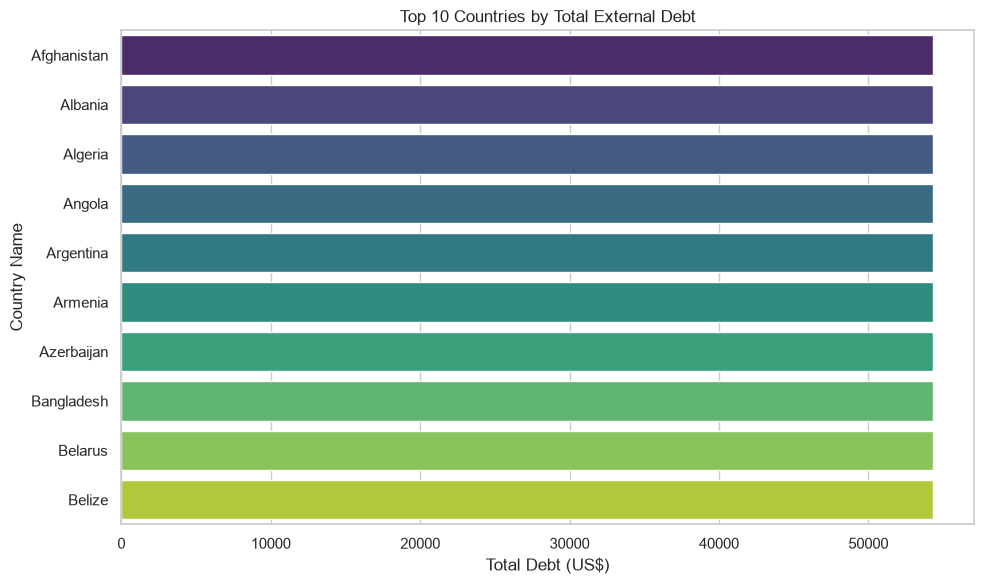

In [62]:
top10 = country_totals.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index,hue=top10.index,palette='viridis',legend=False)
plt.xlabel('Total Debt (US$)')
plt.title('Top 10 Countries by Total External Debt')
plt.tight_layout()
plt.show()

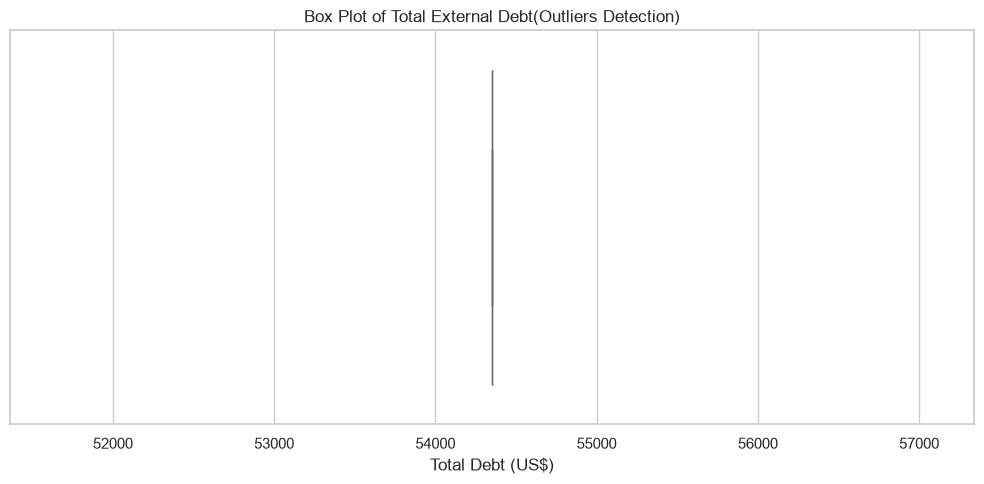

In [63]:
top10 = country_totals.head(10)
plt.figure(figsize=(10, 5))
sns.boxplot(x=country_totals,color='skyblue')
plt.xlabel('Total Debt (US$)')

plt.title('Box Plot of Total External Debt(Outliers Detection)')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_4528\2999151190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom5.values, y=bottom5.index, palette='rocket')


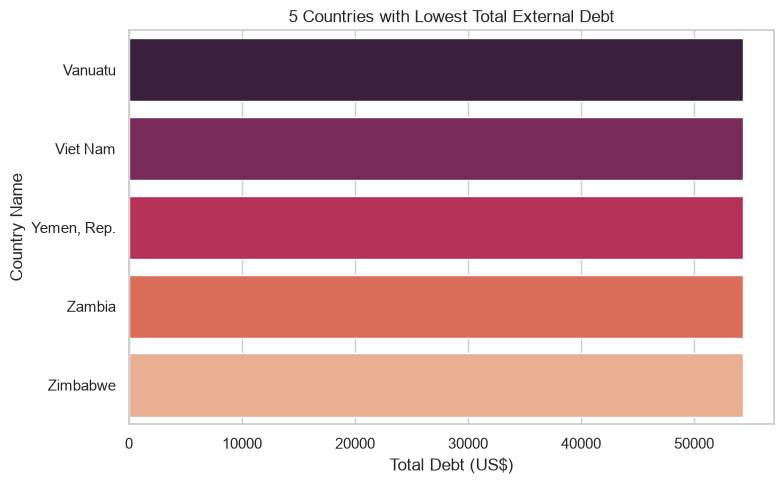

In [64]:
bottom5 = country_totals.tail(5)
plt.figure(figsize=(8, 5))
sns.barplot(x=bottom5.values, y=bottom5.index, palette='rocket')
plt.xlabel('Total Debt (US$)')
plt.title('5 Countries with Lowest Total External Debt')
plt.tight_layout()
plt.show()

In [65]:

indicators = df.columns.drop(['Country Name', 'Country Code', 'Year'])


df_long = df.melt(id_vars=['Year'], value_vars=indicators, var_name='Indicator', value_name='Value')


In [66]:
df_grouped = df_long.groupby(['Indicator', 'Year'])['Value'].mean().reset_index()




In [67]:
df_long['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026])

In [68]:
df_long['Indicator'].unique()

<ArrowStringArray>
[          'Average grace period on new external debt commitments (years)',
 'Average grace period on new external debt commitments, official (years)',
  'Average grace period on new external debt commitments, private (years)',
              'Average grant element on new external debt commitments (%)',
    'Average grant element on new external debt commitments, official (%)',
     'Average grant element on new external debt commitments, private (%)',
                   'Average interest on new external debt commitments (%)',
         'Average interest on new external debt commitments, official (%)',
          'Average interest on new external debt commitments, private (%)',
               'Average maturity on new external debt commitments (years)',
 ...
                                    'Total external debt per capita (US$)',
                               'Total reserves (% of total external debt)',
                             'Total reserves (includes gold, cur

C:\Users\admin\AppData\Local\Temp\ipykernel_4528\146751452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indicator_totals.values, y=indicator_totals.index, palette='mako')


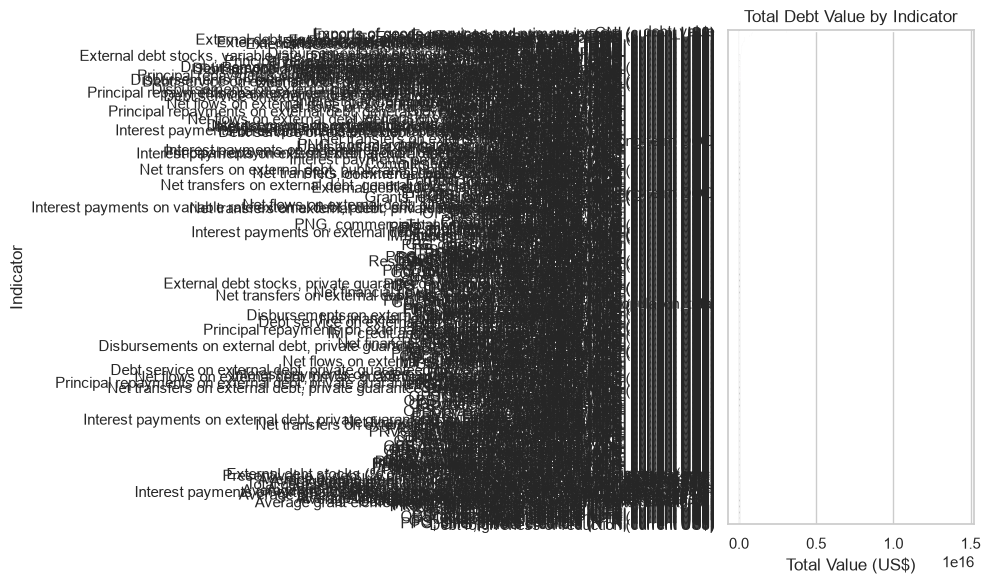

In [69]:
indicator_totals = df_long.groupby('Indicator')['Value'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=indicator_totals.values, y=indicator_totals.index, palette='mako')
plt.xlabel('Total Value (US$)')
plt.title('Total Debt Value by Indicator')
plt.tight_layout()
plt.show()

In [70]:
corr = df.drop(columns=['Country Name','Country Code']).corr()

In [71]:
df.columns

Index(['Country Name', 'Country Code', 'Year',
       'Average grace period on new external debt commitments (years)',
       'Average grace period on new external debt commitments, official (years)',
       'Average grace period on new external debt commitments, private (years)',
       'Average grant element on new external debt commitments (%)',
       'Average grant element on new external debt commitments, official (%)',
       'Average grant element on new external debt commitments, private (%)',
       'Average interest on new external debt commitments (%)',
       ...
       'Total external debt per capita (US$)',
       'Total reserves (% of total external debt)',
       'Total reserves (includes gold, current US$)',
       'Total reserves in months of imports',
       'Undisbursed external debt, official creditors (UND, current US$)',
       'Undisbursed external debt, private creditors (UND, current US$)',
       'Undisbursed external debt, total (UND, current US$)',
       